## EXECUTION FLOW DIAGRAM

![Flow Diagram](images/flow_diagram.png)

## Importing necessary libraries and packages

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA
from collections import Counter
from sklearn.model_selection import GridSearchCV

## TASK 1: Data Loading and Exploration

In [2]:
df = pd.read_csv('data/MNIST.csv')
df.head()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28,label
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,5
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,4
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,9


### Check for missing values

In [3]:
df.isna()

,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,1x10,...,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28,label
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
69996,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
69997,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
69998,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
df.isna().sum().sum()

np.int64(0)

In [5]:
df.isna().values.any()

np.False_

### Class Distribution and number of samples

In [55]:
df.shape[::]

(70000, 785)

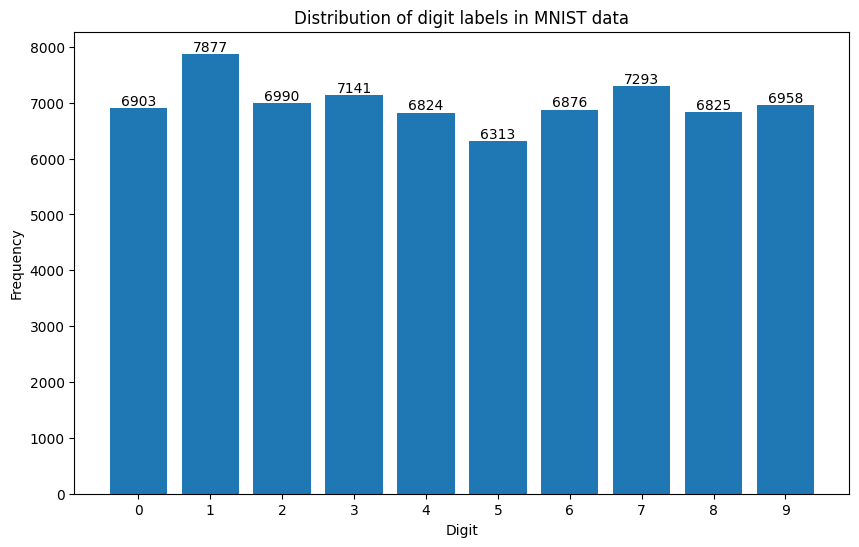

In [32]:
label_counts = df['label'].value_counts().sort_index()


plt.figure(figsize=(10,6))
plt.bar(label_counts.index, label_counts.values)

for i, v in enumerate(label_counts.values):
    plt.text(i, v+50, str(v), ha='center', fontsize=10)

plt.xlabel("Digit")
plt.ylabel("Frequency")
plt.title("Distribution of digit labels in MNIST data")
plt.xticks(range(10))
plt.show()

`From the distribution of digit labels, it is visible that there is no significant class imbalance thereby providing accuracy to be a suitable evaluation metric.`

### Displaying sample images with labels

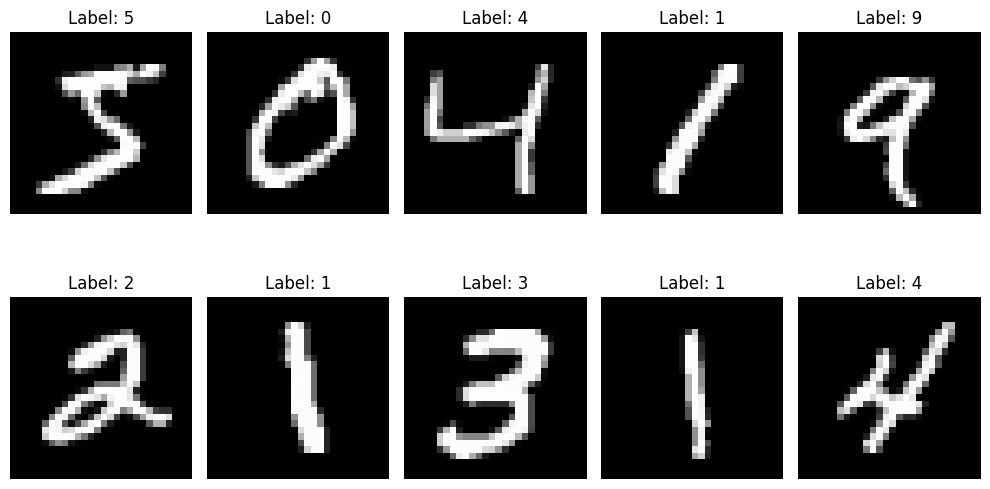

In [ ]:
pixels = df.iloc[:,:-1]  #separating pixel values and target labels
labels = df.iloc[:,-1]

sample_pixels = pixels.iloc[:10]
sample_labels = labels.iloc[:10]

plt.figure(figsize=(10,6))
for i in range(10):
    image = sample_pixels.iloc[i].values.reshape(28,28) #reshaping for image
    label = sample_labels.iloc[i]

    plt.subplot(2,5,i+1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.tight_layout()
plt.show() 



## TASK 2: Data Preprocessing

### Separating features and target column

In [72]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]
print(X.shape, y.shape)

(70000, 784) (70000,)


### Normalizing feature/pixel values

In [172]:
X = X/255.0   #dividing by 255 as 0-255 is the range of pixel values in MNIST digit images.

### Splitting dataset into training and testing sets (80:20 split)

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)


(56000, 784) (14000, 784) (56000,) (14000,)


## TASK 3: Model Implementation

### Implementing KNN algorithm from scratch

In [83]:
class KNN:

    def __init__(self, k=3):
        
        """
        Number of K nearest neighbors. Default = 3

        """
        self.k = k

    def fit(self, X, y):
        
        """
        Storing training data.
        
        """
        self.X_train = X.values if hasattr(X, "values") else X
        self.y_train = y.values if hasattr(y, "values") else y


    def euclidian_distance(self, x1, x2):

        """
        Computing euclian distance between two points.

        """

        return np.sqrt(np.sum((x1-x2)**2))

    def predict(self, X):
        
        """
        To predict labels for input samples X.
        
        """

        X = X.values if hasattr(X, "values") else X
        predictions = []

        for x in X:

            distances = [self.euclidian_distance(x, x_train) for x_train in self.X_train]
            
            k_indices = np.argsort(distances)[:self.k]

            k_labels = self.y_train[k_indices]

            common = Counter(k_labels).most_common(1)
            predictions.append(common[0][0])


        return np.array(predictions)
    

In [104]:
from sklearn.utils import resample

X_sub, y_sub = resample(X_train, y_train, n_samples=3000, random_state=42, stratify=y_train)


In [98]:
k_values = [1,3,5,7,9,11]

train_accuracies = []

for k in k_values:
    knn = KNN(k=k)
    knn.fit(X_sub, y_sub)
    preds = knn.predict(X_sub)
    acc = accuracy_score(y_sub, preds)
    train_accuracies.append(acc)

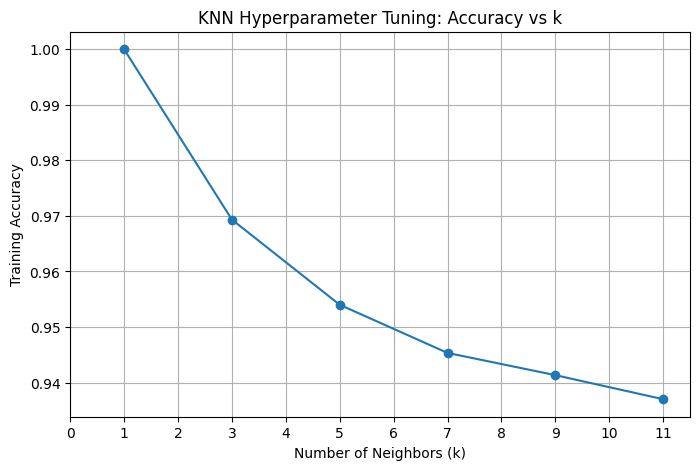

In [101]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o')
plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Training Accuracy")
plt.title("KNN Hyperparameter Tuning: Accuracy vs k")
plt.grid(True)
plt.xticks(range(12))
plt.show()


`Although k = 1 yields the highest training accuracy, it is likely to overfit. A moderate value of k = 5 is chosen as a balance between model complexity and generalization.`

In [141]:
best_knn = KNN(k=5)
best_knn.fit(X_train, y_train)

### SVM without PCA

In [161]:
svm_without_pca = SVC(kernel='rbf')
param_grid = {
    'C' : [1, 5, 10],
    'gamma': ['scale', 0.01, 0.001]
}

In [162]:
X_svm, y_svm = resample(X_train,y_train,n_samples=3000,stratify=y_train)

In [163]:
grid_svm_without_pca = GridSearchCV(
    svm_without_pca,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm_without_pca.fit(X_svm, y_svm)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 5, ...], 'gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate para

In [164]:
best_svm_without_pca = grid_svm_without_pca.best_estimator_
print('Best SVM parameters:', grid_svm_without_pca.best_params_)

Best SVM parameters: {'C': 10, 'gamma': 'scale'}


### Feature/Dimensionality reduction using PCA for SVM

In [106]:
pca = PCA(n_components=0.95, random_state=42)

X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Reduced dimensions:", X_train_pca.shape[1])

Reduced dimensions: 154


In [108]:
svm = SVC(kernel='rbf')
param_grid = {
    'C': [1, 5, 10],
    'gamma': ['scale', 0.01, 0.001] 
}

`Due to high computation time required for 56,000 samples for RBF-kernel training, a subset of 5,000 samples is used for training the final model on the full training set.`

In [ ]:
X_svm_sub, y_svm_sub = resample(X_train_pca,y_train,n_samples=5000,stratify=y_train)

In [142]:
grid_svm = GridSearchCV(
    svm,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_svm.fit(X_svm_sub, y_svm_sub)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [1, 5, ...], 'gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate para

In [ ]:
best_svm = grid_svm.best_estimator_
print('Best SVM parameters:', grid_svm.best_params_)

Best SVM parameters: {'C': 10, 'gamma': 'scale'}


### Decision Tree Classifier

In [136]:
dt = DecisionTreeClassifier(random_state=42)

In [137]:
X_dt_sub, y_dt_sub = resample(X_train,y_train,n_samples=5000,stratify=y_train)

In [138]:
param_grid_dt = {
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10]
}


In [139]:
grid_dt = GridSearchCV(
    dt,
    param_grid_dt,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid_dt.fit(X_dt_sub, y_dt_sub)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",DecisionTreeC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'min_samples_split': [2, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displa

In [140]:
best_dt = grid_dt.best_estimator_
print("Best Decision Tree parameters:", grid_dt.best_params_)


Best Decision Tree parameters: {'max_depth': 10, 'min_samples_split': 5}


### Training all models on full training data

In [165]:
best_knn = KNN(k=5)
best_knn.fit(X_train, y_train)


best_svm_without_pca = SVC(**grid_svm_without_pca.best_params_)
best_svm_without_pca.fit(X_train, y_train)

best_svm = SVC(**grid_svm.best_params_)
best_svm.fit(X_train_pca, y_train)


best_dt = DecisionTreeClassifier(**grid_dt.best_params_, random_state=42)
best_dt.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current n

## Task 4: Model Evaluation

In [173]:
X_test = X_test.reset_index(drop=True)   #reset index to convert label indexing to positional indexing
y_test = y_test.reset_index(drop=True)


In [156]:
X_test_sub, y_test_sub = resample(
    X_test,
    y_test,
    n_samples=100,
    random_state=42,
    stratify=y_test
)

In [167]:
sub_idx = X_test_sub.index
X_test_pca_sub = X_test_pca[sub_idx]


In [ ]:
y_pred_svm_sub = best_svm.predict(X_test_pca_sub)


### KNN Evaluation

KNN Evaluation (Subset)
KNN Accuracy (subset): 0.9700
[[10  0  0  0  0  0  0  0  0  0]
 [ 0 11  0  0  0  0  0  0  0  0]
 [ 0  0 10  0  0  0  0  0  0  0]
 [ 1  0  0  9  0  0  0  0  0  0]
 [ 0  0  0  0  9  0  0  0  0  1]
 [ 0  0  0  0  0  9  0  0  0  0]
 [ 0  0  0  0  0  0 10  0  0  0]
 [ 0  0  0  0  0  0  0 10  0  0]
 [ 0  0  0  0  0  0  0  0 10  0]
 [ 0  0  0  0  1  0  0  0  0  9]]


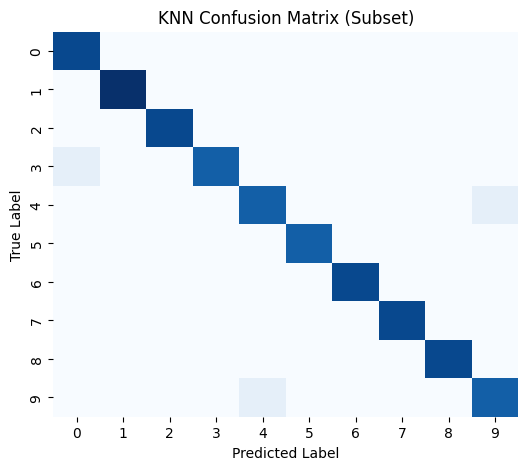

In [158]:
print("KNN Evaluation (Subset)")

y_pred_knn = best_knn.predict(X_test_sub)
acc_knn = accuracy_score(y_test_sub, y_pred_knn)
print(f"KNN Accuracy (subset): {acc_knn:.4f}")

cm_knn = confusion_matrix(y_test_sub, y_pred_knn)
print(cm_knn)

plt.figure(figsize=(6,5))
sns.heatmap(cm_knn, cmap="Blues", cbar=False)
plt.title("KNN Confusion Matrix (Subset)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### SVM without PCA Evaluation

SVM Evaluation without PCA
SVM Accuracy: 0.9834
[[1377    1    0    0    0    1    0    0    1    1]
 [   0 1561    5    1    1    0    0    4    3    0]
 [   5    1 1374    2    2    0    1    7    4    2]
 [   1    2    6 1399    0    7    0    8    5    0]
 [   2    3    1    0 1335    0    5    2    0   17]
 [   2    0    0    6    4 1236    8    0    5    2]
 [   9    2    1    0    2    2 1358    0    1    0]
 [   2    3    7    1    6    0    0 1431    0    9]
 [   2    3    4    4    1    7    2    1 1336    5]
 [   1    6    0    5    7    3    0    6    2 1361]]


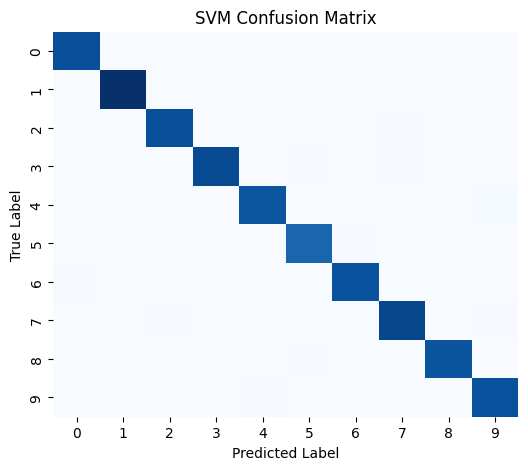

In [166]:
print("SVM Evaluation without PCA")

y_pred_svm = best_svm_without_pca.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")

cm_svm_without_pca = confusion_matrix(y_test, y_pred_svm)
print(cm_svm_without_pca)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm_without_pca, cmap="Blues", cbar=False)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### SVM with PCA Evaluation

SVM Evaluation (Full Test Set)
SVM Accuracy: 0.9859
[[1377    1    0    0    0    1    0    0    1    1]
 [   0 1560    8    0    1    0    0    4    2    0]
 [   3    0 1381    1    2    0    1    5    4    1]
 [   1    1    5 1402    0    6    0    6    6    1]
 [   1    4    1    0 1339    0    4    2    0   14]
 [   2    0    0    7    2 1238    8    0    3    3]
 [   5    2    0    0    2    1 1364    0    1    0]
 [   2    3    7    0    5    0    0 1434    0    8]
 [   2    3    1    4    0    4    3    1 1343    4]
 [   1    6    0    4    6    3    0    5    1 1365]]


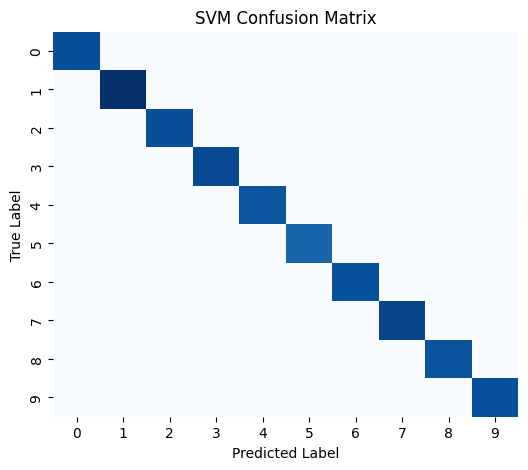

In [153]:
print("SVM Evaluation (Full Test Set)")

y_pred_svm = best_svm.predict(X_test_pca)
acc_svm = accuracy_score(y_test, y_pred_svm)
print(f"SVM Accuracy: {acc_svm:.4f}")

cm_svm = confusion_matrix(y_test, y_pred_svm)
print(cm_svm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_svm, cmap="Blues", cbar=False)
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

Decision Tree Evaluation (Full Test Set)
Decision Tree Accuracy: 0.8611
[[1288    2   18   13    3   17   14    5   15    6]
 [   1 1508   26    9    9    4    2    8    7    1]
 [  23   12 1185   24   24   17   28   18   48   19]
 [   7    9   52 1176   13   56   13   20   40   42]
 [   7    9   19    4 1167   12   11   12   20  104]
 [  29    7   15   77   20 1016   35    6   27   31]
 [  30   14   25   25   29   44 1179    8   17    4]
 [   4   14   35   31   12   17    2 1297   10   37]
 [  18   28   40   40   25   44   20   15 1083   52]
 [  10   13   21   28   73   30    6   22   32 1156]]


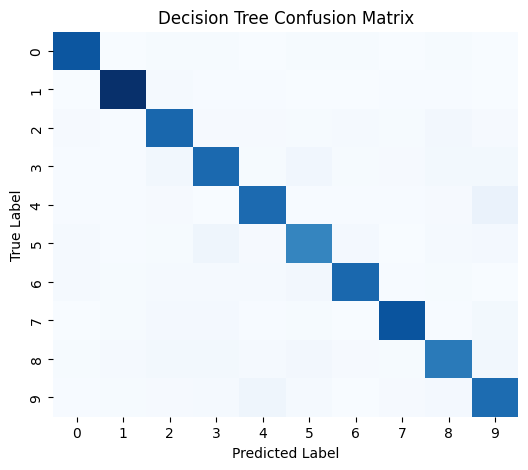

In [154]:
print("Decision Tree Evaluation (Full Test Set)")

y_pred_dt = best_dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
print(f"Decision Tree Accuracy: {acc_dt:.4f}")

cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, cmap="Blues", cbar=False)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

### Misclassifications with SVM (PCA)

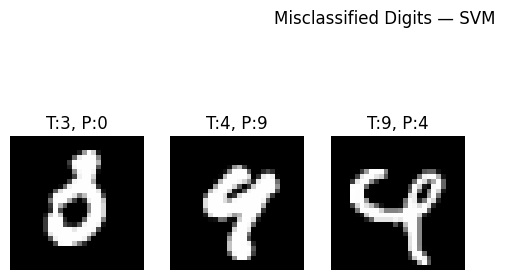

In [170]:
y_pred_svm_sub = best_svm.predict(X_test_pca_sub)
mis_idx_svm = np.where(y_pred_svm_sub != y_test_sub)[0]

plt.figure(figsize=(10, 4))

for i, idx in enumerate(mis_idx_svm[:5]):
    img = X_test_sub.iloc[idx].values.reshape(28, 28)
    true_label = y_test_sub.iloc[idx]
    pred_label = y_pred_svm_sub[idx]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{true_label}, P:{pred_label}")
    plt.axis("off")

plt.suptitle("Misclassified Digits — SVM")
plt.show()

### Misclassifications with Decision Tree

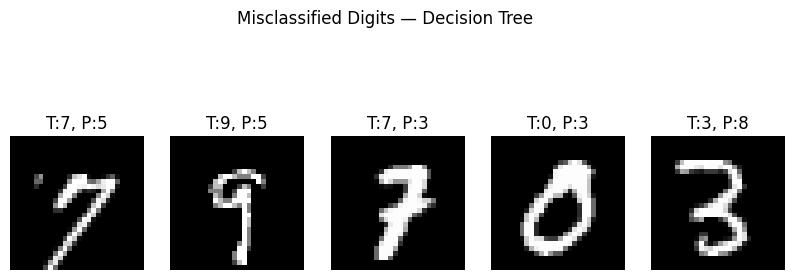

In [171]:
y_pred_dt_sub = best_dt.predict(X_test_sub)
mis_idx_dt = np.where(y_pred_dt_sub != y_test_sub)[0]

plt.figure(figsize=(10, 4))

for i, idx in enumerate(mis_idx_dt[:5]):
    img = X_test_sub.iloc[idx].values.reshape(28, 28)
    true_label = y_test_sub.iloc[idx]
    pred_label = y_pred_dt_sub[idx]

    plt.subplot(1, 5, i + 1)
    plt.imshow(img, cmap="gray")
    plt.title(f"T:{true_label}, P:{pred_label}")
    plt.axis("off")

plt.suptitle("Misclassified Digits — Decision Tree")
plt.show()

## Task 5: Reporting

### OBSERVATIONS
- The accuracy of the KNN model is observed to be approximately **97%**. Since the model is implemented from scratch, a representative subset of the test data is used for evaluation to manage computational complexity. The optimal number of neighbors **(k = 5)** is selected to balance overfitting and generalization.



- The accuracy of SVM with PCA applied is slightly higher than basic SVM model without PCA **(98.34% vs 98.59%)**. In both models, the optimal hyperparameters are observed to be **'C' = 10** and **'gamma' = 'scale'**.



- The decision tree model accuracy is concluded as **86.11%**. The optimal hyperparameters are **max_depth = 10** and **min_samples_split = 5**

### MISCLASSIFICATION ANALYSIS

- As observed in the SVM model (with PCA), some of the misclassified digits are 4, 9, and 3. 4 is been mistakenly predicted as 9 and vice-versa. Similarly, in decision tree misclassifications, 7, 9, or 0 are mistakenly predicted as 5 or 3, while 3 is being predicted falsely as 8. 


- The misclassifications primarily arise due to the loss of spatial information when images are flattened into one-dimensional feature vectors, making it difficult for classical machine learning models to capture subtle structural differences in handwritten digits.

### SUGGESTIONS FOR IMPROVEMENT

- Techniques like image augmentation and using CNN models to learn spatial complexity can be used for improved inference.